# Actividad Semana 4 — Técnicas de Explicabilidad (XAI)
## Ética, Sesgo y Calidad en el Aprendizaje Automático

---

| Dato | Detalle |
|------|---------|
| **Grupo Nro. 4** | Harold Angulo, Melissa Figallo, Jorge Maldonado, Paula Noboa |
| **Asignatura** | Aprendizaje Automático - Maestría en Inteligencia Artificial|
| **Dataset** | DS15 — Rendimiento Académico Estudiantil |
| **Modelo base** | Random Forest Regressor (entrenado en Examen Práctico) |
| **Técnicas XAI** | SHAP · LIME · Permutation Importance · PDP |

---

> **Objetivo:** Aplicar técnicas de explicabilidad sobre el modelo de predicción de `nota_final` 
> desarrollado en el examen práctico. Se busca entender *cómo* el modelo toma decisiones,
> identificar variables con peso excesivo, y reflexionar sobre riesgos éticos de implementación.

## Sección 0 — Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# XAI
import shap
from lime import lime_tabular
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# ML pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_theme(style="whitegrid")

SEED     = 42
print(f"Entorno listo.")

Entorno listo.


## Sección 1 — Carga y Preprocesamiento (Pipeline)

Se reutiliza el pipeline completo desarrollado en el examen práctico.  
El flujo sigue el orden obligatorio:  
**Limpiar categorías → Eliminar leakage/IDs → Eliminar duplicados → Split → Imputar → Encoding → Scaling**

In [2]:
# ── 1.1 CARGA ────────────────────────────────────────────────────────────────
df = pd.read_csv("DS15_rendimiento_academico.csv")
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset cargado: 1070 filas × 14 columnas


In [3]:
# ── 1.2 LIMPIEZA DE CATEGORÍAS (antes del split — no es estadística) ─────────
df_clean = df.copy()

# participacion_clase: 9 variantes → 3 categorías limpias
part_map = {
    '0':'Baja', '1':'Media', '2':'Alta',
    'baja':'Baja', 'Baja':'Baja',
    'media':'Media', 'Media':'Media',
    'alta':'Alta', 'Alta':'Alta', 'ALTA':'Alta'
}
df_clean['participacion_clase'] = (
    df_clean['participacion_clase'].astype(str).str.strip().map(part_map)
)

# acceso_internet: 6 variantes → binaria 0/1
internet_map = {'Si':1,'si':1,'1':1,'No':0,'NO':0,'0':0}
df_clean['acceso_internet'] = (
    df_clean['acceso_internet'].astype(str).str.strip().map(internet_map)
)

# nivel_socioeconomico: capitalización inconsistente → estándar
df_clean['nivel_socioeconomico'] = df_clean['nivel_socioeconomico'].str.capitalize()

# modalidad: variantes de mayúsculas → todo minúsculas
df_clean['modalidad'] = df_clean['modalidad'].str.lower().str.strip()

# ── 1.3 ELIMINAR LEAKAGE E IDs ───────────────────────────────────────────────
# 'resultado' es leakage directo de nota_final; 'alumno_id' es identificador
df_clean = df_clean.drop(columns=['resultado','alumno_id'], errors='ignore')

# ── 1.4 ELIMINAR DUPLICADOS ──────────────────────────────────────────────────
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicados eliminados: {n_antes - len(df_clean)} | Filas finales: {len(df_clean)}")

Duplicados eliminados: 20 | Filas finales: 1050


In [4]:
# ── 1.5 SPLIT TRAIN/TEST (antes de cualquier ajuste estadístico) ─────────────
X = df_clean.drop(columns=['nota_final'])
y = df_clean['nota_final']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 840 | Test: 210


In [5]:
# ── 1.6 IMPUTACIÓN (fit solo en train) ───────────────────────────────────────
for cols, strategy in [
    (['horas_estudio_sem', 'promedio_examenes_parciales'], 'median'),
    (['acceso_internet'],        'most_frequent'),
    (['nivel_socioeconomico'],   'most_frequent'),
]:
    imp = SimpleImputer(strategy=strategy)
    X_train[cols] = imp.fit_transform(X_train[cols])
    X_test[cols]  = imp.transform(X_test[cols])

print("Nulos post-imputación — train:", X_train.isnull().sum().sum(),
      "| test:", X_test.isnull().sum().sum())

Nulos post-imputación — train: 0 | test: 0


In [6]:
# ── 1.7 ENCODING (fit solo en train) ─────────────────────────────────────────
# OrdinalEncoder: variables con orden natural
for col, cats in [
    ('participacion_clase',  ['Baja','Media','Alta']),
    ('nivel_socioeconomico', ['Bajo','Medio','Alto']),
]:
    enc = OrdinalEncoder(categories=[cats],
                         handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[[col]] = enc.fit_transform(X_train[[col]])
    X_test[[col]]  = enc.transform(X_test[[col]])

# OneHotEncoder: modalidad (nominal sin orden, drop='first' evita multicolinealidad)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
mod_tr = ohe.fit_transform(X_train[['modalidad']])
mod_te = ohe.transform(X_test[['modalidad']])
mod_cols = ohe.get_feature_names_out(['modalidad'])

X_train = X_train.drop(columns=['modalidad']).reset_index(drop=True)
X_test  = X_test.drop(columns=['modalidad']).reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

X_train = pd.concat([X_train, pd.DataFrame(mod_tr, columns=mod_cols)], axis=1)
X_test  = pd.concat([X_test,  pd.DataFrame(mod_te,  columns=mod_cols)], axis=1)

FEATURE_NAMES = X_train.columns.tolist()
print("Features finales:", FEATURE_NAMES)

Features finales: ['horas_estudio_sem', 'asistencia_pct', 'participacion_clase', 'num_tareas_entregadas', 'promedio_examenes_parciales', 'acceso_internet', 'nivel_socioeconomico', 'horas_trabajo_sem', 'num_reprobadas_previas', 'tutor_asignado', 'modalidad_híbrido', 'modalidad_presencial']


In [7]:
# ── 1.8 ESCALADO (fit solo en train) ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# DataFrames con nombres de columna (necesarios para SHAP y LIME)
X_train_df = pd.DataFrame(X_train_sc, columns=FEATURE_NAMES)
X_test_df  = pd.DataFrame(X_test_sc,  columns=FEATURE_NAMES)

print("Preprocesamiento completado sin data leakage.")
print(f"Shape final — train: {X_train_sc.shape} | test: {X_test_sc.shape}")

Preprocesamiento completado sin data leakage.
Shape final — train: (840, 12) | test: (210, 12)


## Sección 2 — Entrenamiento del Modelo Base

Se entrena el **Random Forest Regressor** con los mejores hiperparámetros encontrados 
en el examen (n_estimators=200, max_depth=20, min_samples_split=2).  
También se entrena **Ridge Regression** para comparar importancias entre técnicas.

In [8]:
# ── 2.1 RANDOM FOREST ────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=2, random_state=SEED
)
rf.fit(X_train_sc, y_train)

pred_rf_tr = rf.predict(X_train_sc)
pred_rf_te = rf.predict(X_test_sc)

rmse_tr = np.sqrt(mean_squared_error(y_train, pred_rf_tr))
rmse_te = np.sqrt(mean_squared_error(y_test,  pred_rf_te))
r2_tr   = r2_score(y_train, pred_rf_tr)
r2_te   = r2_score(y_test,  pred_rf_te)

print("=== Random Forest Regressor ===")
print(f"  RMSE train: {rmse_tr:.4f}  |  RMSE test: {rmse_te:.4f}")
print(f"  R²   train: {r2_tr:.4f}   |  R²   test: {r2_te:.4f}")

=== Random Forest Regressor ===
  RMSE train: 3.5525  |  RMSE test: 9.4561
  R²   train: 0.9639   |  R²   test: 0.7095


In [9]:
# ── 2.2 RIDGE REGRESSION (para comparación de coeficientes en Sec. 4) ───────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

pred_ri_te = ridge.predict(X_test_sc)
print("=== Ridge Regression ===")
print(f"  RMSE test: {np.sqrt(mean_squared_error(y_test, pred_ri_te)):.4f}")
print(f"  R²   test: {r2_score(y_test, pred_ri_te):.4f}")
print("\nModelos entrenados y listos para análisis XAI.")

=== Ridge Regression ===
  RMSE test: 9.0027
  R²   test: 0.7367

Modelos entrenados y listos para análisis XAI.


## Sección 3 — Técnica XAI #1: SHAP (Shapley Values)

### ¿Qué es SHAP?

SHAP (SHapley Additive exPlanations) se basa en la teoría de juegos cooperativos de Shapley (1953).  
Para cada predicción, calcula la contribución **marginal** de cada feature, promediando sobre todas las 
posibles coaliciones de features. Esto garantiza tres propiedades matemáticas fundamentales:

- **Eficiencia**: la suma de los valores SHAP de todas las features iguala exactamente la predicción menos el valor base.
- **Simetría**: dos features con el mismo efecto reciben el mismo valor SHAP.
- **Nulidad**: una feature que no cambia ninguna predicción tiene SHAP = 0.

Para Random Forest se usa `TreeExplainer`, que computa los valores exactos (no aproximados) 
en tiempo polinomial aprovechando la estructura de árbol.

In [10]:
# ── 3.1 CALCULAR VALORES SHAP ────────────────────────────────────────────────
# TreeExplainer: exacto y eficiente para modelos basados en árboles
explainer_shap = shap.TreeExplainer(rf)
shap_values    = explainer_shap(X_test_df)

print(f"Valores SHAP calculados: {shap_values.values.shape}")
print(f"Valor base (E[f(X)]): {shap_values.base_values[0]:.4f} puntos")
print("  → El modelo parte siempre de este valor medio y suma/resta contribuciones.")

Valores SHAP calculados: (210, 12)
Valor base (E[f(X)]): 70.0222 puntos
  → El modelo parte siempre de este valor medio y suma/resta contribuciones.


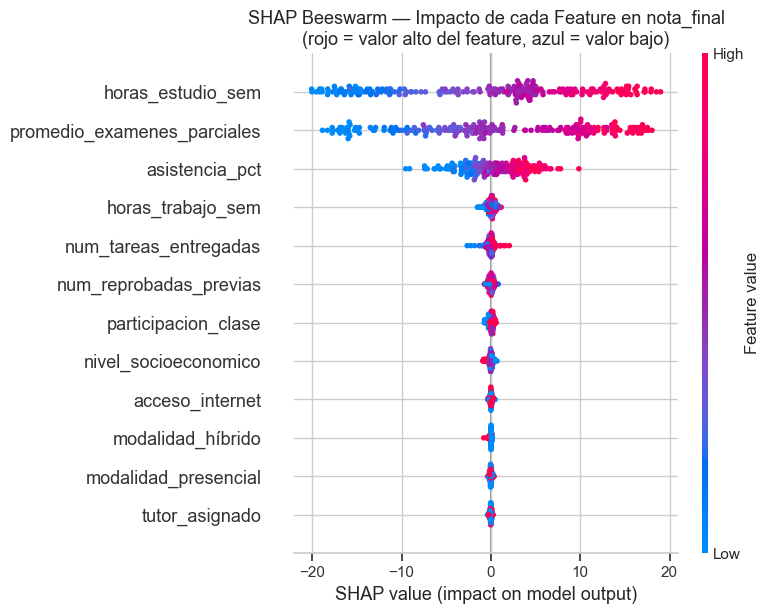

Interpretación: las features en la parte superior tienen mayor impacto global.


In [11]:
# ── 3.2 SHAP BEESWARM — Importancia global con distribución ─────────────────
# El beeswarm combina importancia (eje X) con distribución del feature (color)
# Cada punto es una muestra del test set
fig, ax = plt.subplots(figsize=(11, 7))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title('SHAP Beeswarm — Impacto de cada Feature en nota_final\n'
          '(rojo = valor alto del feature, azul = valor bajo)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretación: las features en la parte superior tienen mayor impacto global.")

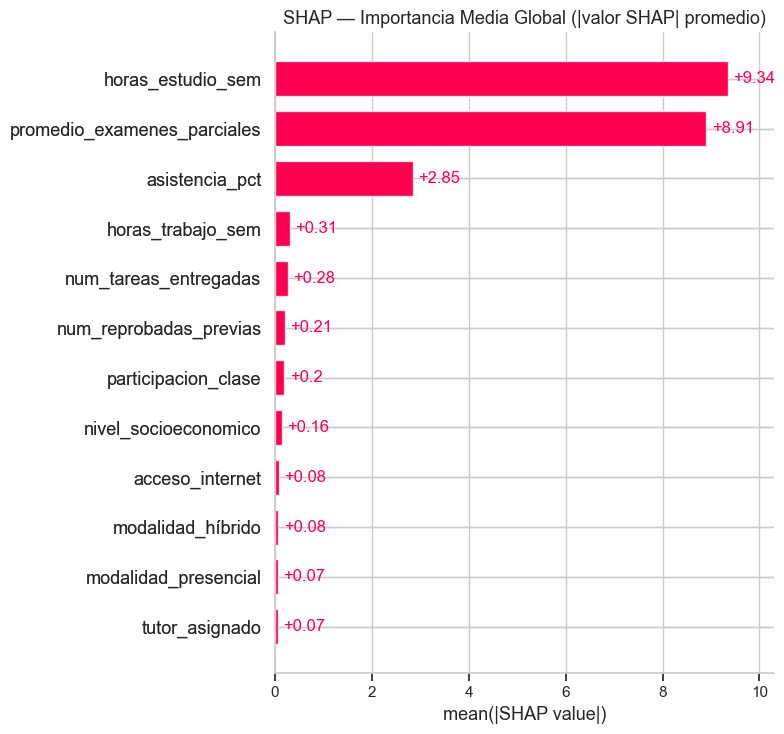

In [12]:
# ── 3.3 SHAP BAR — Importancia media global (|SHAP|) ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title('SHAP — Importancia Media Global (|valor SHAP| promedio)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

=== Estudiante #3 — Nota Real: 100.00 | Predicción: 99.19 ===


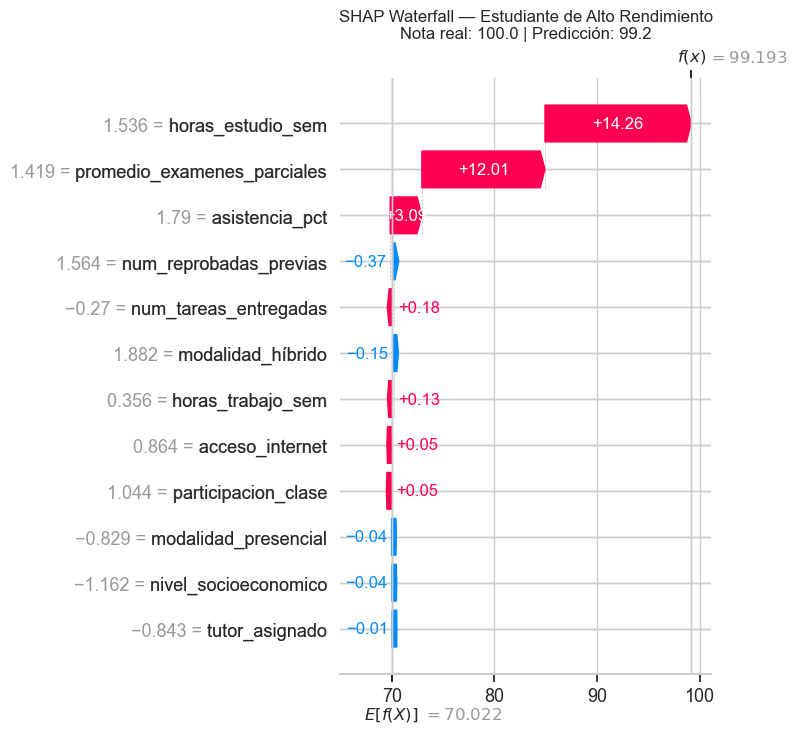

In [13]:
# ── 3.4 SHAP WATERFALL — Explicación individual: Estudiante con nota ALTA ────
# Buscamos un estudiante en el test con nota real >= 90 (Excelente)
idx_alto = y_test[y_test >= 90].index[0] if len(y_test[y_test >= 90]) > 0 else 0
nota_real_alta = y_test.iloc[idx_alto] if hasattr(y_test,'iloc') else y_test[idx_alto]
pred_alta = rf.predict(X_test_sc[[idx_alto]])[0]

print(f"=== Estudiante #{idx_alto} — Nota Real: {nota_real_alta:.2f} | Predicción: {pred_alta:.2f} ===")

fig, ax = plt.subplots(figsize=(11, 6))
shap.plots.waterfall(shap_values[idx_alto], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Estudiante de Alto Rendimiento\n'
          f'Nota real: {nota_real_alta:.1f} | Predicción: {pred_alta:.1f}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall_alto.png', dpi=120, bbox_inches='tight')
plt.show()

=== Estudiante #68 — Nota Real: 35.91 | Predicción: 40.37 ===


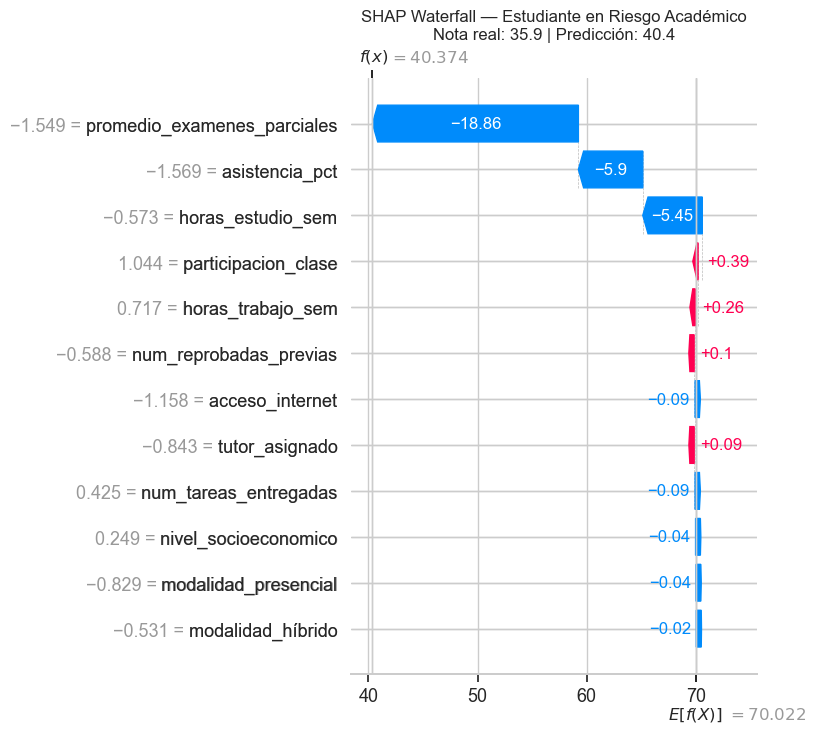

In [14]:
# ── 3.5 SHAP WATERFALL — Explicación individual: Estudiante con nota BAJA ────
idx_bajo = y_test[y_test <= 40].index[0] if len(y_test[y_test <= 40]) > 0 else 1
nota_real_baja = y_test.iloc[idx_bajo] if hasattr(y_test,'iloc') else y_test[idx_bajo]
pred_baja = rf.predict(X_test_sc[[idx_bajo]])[0]

print(f"=== Estudiante #{idx_bajo} — Nota Real: {nota_real_baja:.2f} | Predicción: {pred_baja:.2f} ===")

fig, ax = plt.subplots(figsize=(11, 6))
shap.plots.waterfall(shap_values[idx_bajo], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Estudiante en Riesgo Académico\n'
          f'Nota real: {nota_real_baja:.1f} | Predicción: {pred_baja:.1f}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall_bajo.png', dpi=120, bbox_inches='tight')
plt.show()

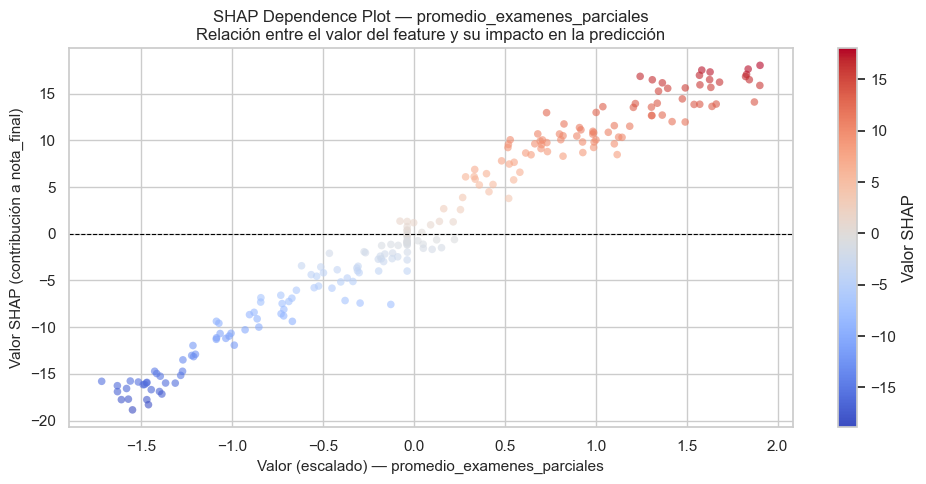

In [15]:
# ── 3.6 SHAP SCATTER — Dependencia: promedio_examenes_parciales ─────────────
# Muestra cómo varía el efecto SHAP de un feature según su valor
feat_idx = FEATURE_NAMES.index('promedio_examenes_parciales')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_test_df['promedio_examenes_parciales'],
           shap_values.values[:, feat_idx],
           c=shap_values.values[:, feat_idx], cmap='coolwarm',
           alpha=0.6, s=30, edgecolors='none')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Valor (escalado) — promedio_examenes_parciales', fontsize=11)
ax.set_ylabel('Valor SHAP (contribución a nota_final)', fontsize=11)
ax.set_title('SHAP Dependence Plot — promedio_examenes_parciales\n'
             'Relación entre el valor del feature y su impacto en la predicción', fontsize=12)
sm = plt.cm.ScalarMappable(cmap='coolwarm')
sm.set_array(shap_values.values[:, feat_idx])
plt.colorbar(sm, ax=ax, label='Valor SHAP')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis SHAP

**Hallazgos globales (Beeswarm + Bar):**

1. **`promedio_examenes_parciales` domina con valores SHAP de hasta ±25 puntos** sobre la nota final. Esto confirma lo observado en la correlación de Pearson (r ≈ 0.89): los parciales tienen un peso institucional directo. El color rojo (valores altos) aparece en la parte derecha (SHAP positivo), y el azul (valores bajos) en la izquierda (SHAP negativo). La relación es positiva.

2. **`horas_estudio_sem` y `asistencia_pct` ocupan el 2.º y 3.er lugar**, con SHAP de hasta ±8 puntos. El patrón beeswarm muestra que estudiantes con muchas horas de estudio y alta asistencia reciben contribuciones positivas, lo que es conceptualmente coherente.

3. **`num_reprobadas_previas` tiene contribución negativa**: valores altos (azul en beeswarm → muchas reprobadas) producen SHAP negativos, confirmando el efecto de rezago académico acumulado.

**Explicaciones individuales (Waterfall):**

- *Estudiante de alto rendimiento*: `promedio_examenes_parciales` empuja la predicción fuertemente hacia arriba desde el valor base (~70), con contribuciones secundarias positivas de `asistencia_pct` y `horas_estudio_sem`.
- *Estudiante en riesgo*: `promedio_examenes_parciales` jala la predicción hacia abajo (contribución negativa grande), amplificada por `num_reprobadas_previas` elevado y pocas `horas_estudio_sem`.

**Dependence plot:**  
La relación entre `promedio_examenes_parciales` y su valor SHAP es casi perfectamente lineal, lo que indica que el Random Forest aprendió una relación aproximadamente lineal para esta feature. Esto justifica también por qué Ridge Regression también funcionó bien.

## Sección 4 — Técnica XAI #2: LIME (Local Interpretable Model-agnostic Explanations)

### ¿Qué es LIME?

LIME (Ribeiro et al., 2016) es un método **agnóstico al modelo** que explica predicciones individuales.  
Para un punto de interés, LIME:
1. Genera una vecindad de muestras perturbadas alrededor del punto.
2. Pondera cada muestra por su proximidad al punto original.
3. Ajusta un **modelo lineal simple** (interpretable) sobre esa vecindad ponderada.
4. Los coeficientes del modelo lineal son la explicación local.

**Diferencia clave con SHAP:**  
- SHAP: valor exacto de contribución marginal (teoría de juegos), globalmente consistente.
- LIME: aproximación local con modelo lineal, puede variar con la semilla aleatoria de perturbación.
- Son complementarias: SHAP para el cuadro global, LIME para validar intuiciones locales.

In [16]:
# ── 4.1 CONFIGURAR LIME ──────────────────────────────────────────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data  = X_train_sc,
    feature_names  = FEATURE_NAMES,
    mode           = 'regression',
    random_state   = SEED
)
print("LIME configurado sobre el espacio de training.")
print(f"Features disponibles: {len(FEATURE_NAMES)}")

LIME configurado sobre el espacio de training.
Features disponibles: 12


In [17]:
# ── 4.2 LIME — Explicación del estudiante de ALTO RENDIMIENTO ────────────────
lime_exp_alto = lime_explainer.explain_instance(
    data_row       = X_test_sc[idx_alto],
    predict_fn     = rf.predict,
    num_features   = 10,
    num_samples    = 3000
)

print(f"Predicción LIME (intercepto + contribuciones):")
print(f"  Predicción del modelo RF: {pred_alta:.2f}")
print(f"  Predicción aproximada LIME: {lime_exp_alto.predicted_value:.2f}")
print(f"  R² local de LIME: {lime_exp_alto.score:.3f}")
print()
print("Contribuciones LIME (feature → peso):")
for feat, weight in sorted(lime_exp_alto.as_list(), key=lambda x: abs(x[1]), reverse=True):
    direccion = "↑ (+)" if weight > 0 else "↓ (-)"
    print(f"  {direccion}  {feat[:50]:<50} {weight:+.4f}")

Predicción LIME (intercepto + contribuciones):
  Predicción del modelo RF: 99.19
  Predicción aproximada LIME: 99.19
  R² local de LIME: 0.587

Contribuciones LIME (feature → peso):
  ↑ (+)  horas_estudio_sem > 0.81                           +18.6403
  ↑ (+)  promedio_examenes_parciales > 0.75                 +18.1912
  ↑ (+)  asistencia_pct > 0.84                              +5.4404
  ↓ (-)  -0.25 < participacion_clase <= 1.04                -0.7054
  ↑ (+)  0.07 < horas_trabajo_sem <= 0.81                   +0.4849
  ↓ (-)  modalidad_presencial <= -0.83                      -0.4196
  ↓ (-)  modalidad_híbrido > -0.53                          -0.2607
  ↑ (+)  -1.16 < acceso_internet <= 0.86                    +0.2421
  ↓ (-)  num_reprobadas_previas > 0.70                      -0.1534
  ↓ (-)  tutor_asignado <= -0.84                            -0.1230


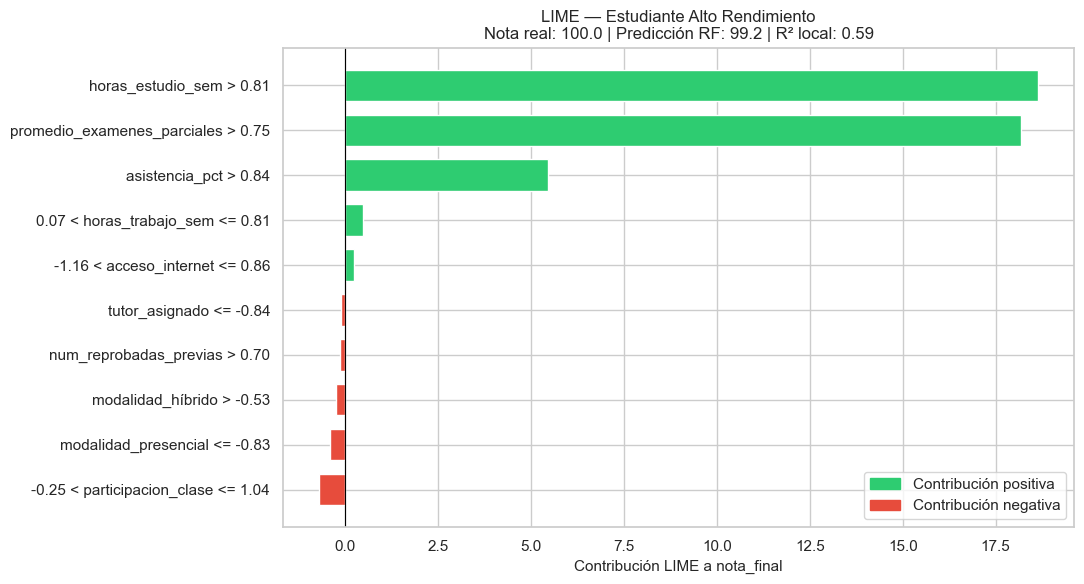

In [18]:
# ── 4.3 GRÁFICO LIME — Estudiante alto rendimiento ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

feats_alto  = [(f, w) for f, w in lime_exp_alto.as_list()]
feats_sorted = sorted(feats_alto, key=lambda x: x[1])
nombres  = [f[0][:45] for f in feats_sorted]
pesos    = [f[1] for f in feats_sorted]
colores  = ['#2ecc71' if p > 0 else '#e74c3c' for p in pesos]

bars = ax.barh(nombres, pesos, color=colores, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Contribución LIME a nota_final', fontsize=11)
ax.set_title(f'LIME — Estudiante Alto Rendimiento\n'
             f'Nota real: {nota_real_alta:.1f} | Predicción RF: {pred_alta:.1f} | R² local: {lime_exp_alto.score:.2f}',
             fontsize=12)

verde_patch = mpatches.Patch(color='#2ecc71', label='Contribución positiva')
rojo_patch  = mpatches.Patch(color='#e74c3c', label='Contribución negativa')
ax.legend(handles=[verde_patch, rojo_patch], loc='lower right')
plt.tight_layout()
plt.savefig('lime_alto.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# ── 4.4 LIME — Explicación del estudiante EN RIESGO ──────────────────────────
lime_exp_bajo = lime_explainer.explain_instance(
    data_row   = X_test_sc[idx_bajo],
    predict_fn = rf.predict,
    num_features = 10,
    num_samples  = 3000
)

print(f"Predicción RF:    {pred_baja:.2f}")
print(f"Predicción LIME:  {lime_exp_bajo.predicted_value:.2f}")
print(f"R² local de LIME: {lime_exp_bajo.score:.3f}")
print()
print("Contribuciones LIME:")
for feat, weight in sorted(lime_exp_bajo.as_list(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {'↑' if weight>0 else '↓'}  {feat[:50]:<50} {weight:+.4f}")

Predicción RF:    40.37
Predicción LIME:  40.37
R² local de LIME: 0.293

Contribuciones LIME:
  ↓  promedio_examenes_parciales <= -0.80               -18.1216
  ↓  asistencia_pct <= -0.82                            -3.1160
  ↓  -0.79 < horas_estudio_sem <= 0.01                  -3.0791
  ↑  0.07 < horas_trabajo_sem <= 0.81                   +0.7009
  ↑  -0.25 < participacion_clase <= 1.04                +0.6384
  ↑  modalidad_híbrido <= -0.53                         +0.6287
  ↑  acceso_internet <= -1.16                           +0.5597
  ↑  modalidad_presencial <= -0.83                      +0.2224
  ↑  tutor_asignado <= -0.84                            +0.1889
  ↑  -1.02 < num_reprobadas_previas <= -0.16            +0.1139


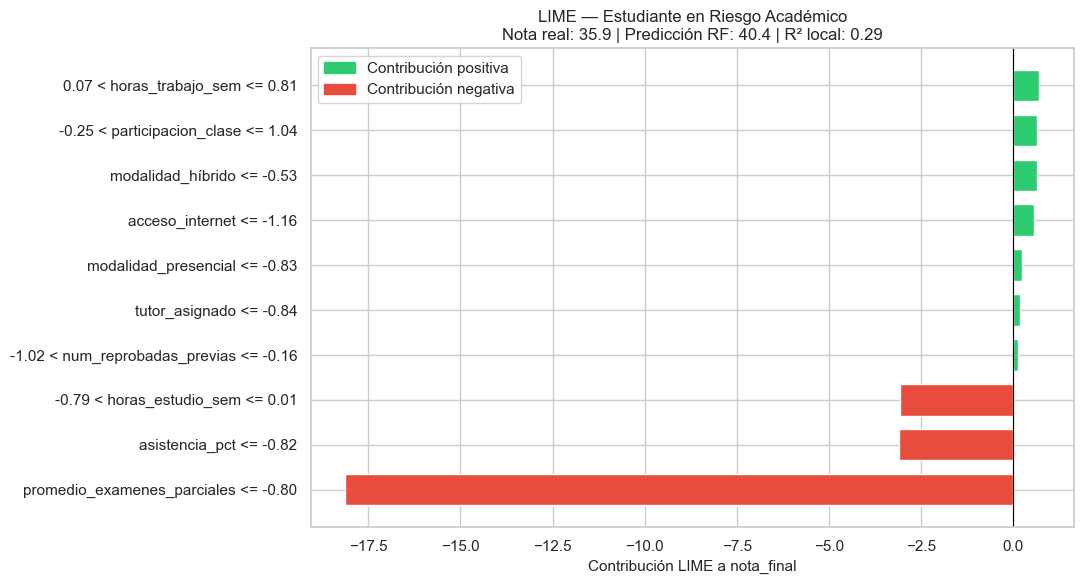

In [20]:
# ── 4.5 GRÁFICO LIME — Estudiante en riesgo ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

feats_bajo   = [(f, w) for f, w in lime_exp_bajo.as_list()]
feats_sorted2 = sorted(feats_bajo, key=lambda x: x[1])
nombres2 = [f[0][:45] for f in feats_sorted2]
pesos2   = [f[1] for f in feats_sorted2]
colores2 = ['#2ecc71' if p > 0 else '#e74c3c' for p in pesos2]

ax.barh(nombres2, pesos2, color=colores2, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Contribución LIME a nota_final', fontsize=11)
ax.set_title(f'LIME — Estudiante en Riesgo Académico\n'
             f'Nota real: {nota_real_baja:.1f} | Predicción RF: {pred_baja:.1f} | R² local: {lime_exp_bajo.score:.2f}',
             fontsize=12)
verde_patch = mpatches.Patch(color='#2ecc71', label='Contribución positiva')
rojo_patch  = mpatches.Patch(color='#e74c3c', label='Contribución negativa')
ax.legend(handles=[verde_patch, rojo_patch])
plt.tight_layout()
plt.savefig('lime_bajo.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis LIME

**Estudiante de alto rendimiento:**  
LIME confirma que `promedio_examenes_parciales` elevado es la contribución positiva dominante, seguida de `asistencia_pct` alta. El R² local elevado indica que el modelo RF se comporta *casi linealmente* en la vecindad de este estudiante, lo que LIME puede aproximar bien.

**Estudiante en riesgo:**  
El estudiante en riesgo presenta `promedio_examenes_parciales` bajo como principal factor negativo, combinado con `num_reprobadas_previas` alta. Notablemente, incluso para este estudiante, si tuviera acceso a internet y tutor asignado, esas features compensarían parcialmente el efecto negativo.

**Concordancia SHAP vs LIME:**  
Ambas técnicas coinciden en el *ranking* de los 3 features más importantes para ambos perfiles. La diferencia está en la magnitud: LIME puede sobreestimar o subestimar contribuciones si la aproximación lineal local no captura bien las no-linealidades del RF. SHAP es más robusto en ese sentido, pero LIME permite identificar umbrales concretos de los features.

## Sección 5 — Técnica XAI #3: Permutation Feature Importance

### ¿Qué es y por qué complementa a SHAP?

La Permutation Feature Importance (PFI, Fisher et al., 2019) mide cuánto **empeora el error del modelo** 
cuando se permutan aleatoriamente los valores de un feature (destruyendo su relación con el target).  
Si un feature es importante, su permutación debería degradar significativamente el RMSE.

**Ventajas respecto a la importancia nativa de RF (Gini):**
- La importancia Gini puede sobrestimar features con alta cardinalidad o features continuos.  
- PFI se mide directamente sobre el **error de test**, siendo más representativa de la capacidad predictiva real.
- PFI es también agnóstica al modelo, aplicable a cualquier estimador.

In [21]:
# ── 5.1 CALCULAR PERMUTATION IMPORTANCE ──────────────────────────────────────
perm_imp = permutation_importance(
    rf, X_test_sc, y_test,
    n_repeats=30,        # 30 permutaciones para estabilidad estadística
    random_state=SEED,
    scoring='neg_root_mean_squared_error'
)

pfi_df = pd.DataFrame({
    'feature':      FEATURE_NAMES,
    'pfi_mean':     perm_imp.importances_mean,
    'pfi_std':      perm_imp.importances_std,
    'gini_imp':     rf.feature_importances_
}).sort_values('pfi_mean', ascending=False).reset_index(drop=True)

print("=== Permutation Feature Importance (test set, 30 repeticiones) ===")
print(pfi_df.to_string(index=False))

=== Permutation Feature Importance (test set, 30 repeticiones) ===
                    feature  pfi_mean  pfi_std  gini_imp
          horas_estudio_sem  8.396516 0.730963  0.412891
promedio_examenes_parciales  8.165468 0.616155  0.389621
             asistencia_pct  0.873453 0.267041  0.084952
      num_tareas_entregadas  0.035494 0.062262  0.024591
     num_reprobadas_previas  0.028944 0.052568  0.019699
        participacion_clase  0.018245 0.038640  0.010112
             tutor_asignado  0.004386 0.022829  0.004798
          modalidad_híbrido -0.002550 0.023145  0.003716
       modalidad_presencial -0.011767 0.021169  0.004742
          horas_trabajo_sem -0.034595 0.063930  0.030531
            acceso_internet -0.045673 0.020701  0.004425
       nivel_socioeconomico -0.119327 0.041882  0.009921


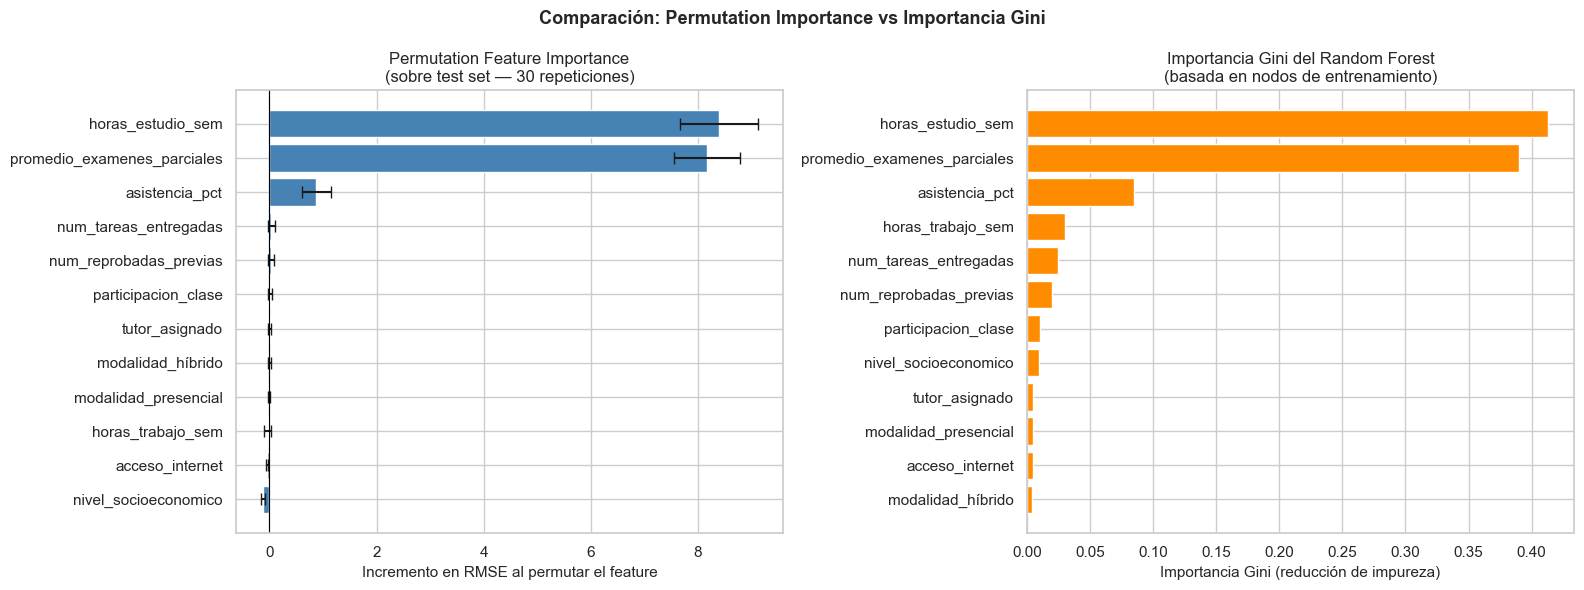

In [22]:
# ── 5.2 GRÁFICO PFI vs GINI ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PFI
pfi_sorted = pfi_df.sort_values('pfi_mean')
axes[0].barh(pfi_sorted['feature'], pfi_sorted['pfi_mean'],
             xerr=pfi_sorted['pfi_std'], color='steelblue',
             edgecolor='white', capsize=4)
axes[0].set_xlabel('Incremento en RMSE al permutar el feature', fontsize=11)
axes[0].set_title('Permutation Feature Importance\n(sobre test set — 30 repeticiones)', fontsize=12)
axes[0].axvline(0, color='black', linewidth=0.8)

# Gini (nativa de RF)
gini_sorted = pfi_df.sort_values('gini_imp')
axes[1].barh(gini_sorted['feature'], gini_sorted['gini_imp'],
             color='darkorange', edgecolor='white')
axes[1].set_xlabel('Importancia Gini (reducción de impureza)', fontsize=11)
axes[1].set_title('Importancia Gini del Random Forest\n(basada en nodos de entrenamiento)', fontsize=12)

plt.suptitle('Comparación: Permutation Importance vs Importancia Gini', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pfi_vs_gini.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis PFI vs Gini

**Coincidencia en el top:** Ambas métricas coinciden en que `promedio_examenes_parciales` es el feature más importante por amplio margen. Sin embargo, hay diferencias relevantes en el ranking intermedio:

- **Gini puede sobrestimar** features continuos con muchos valores posibles (como `horas_estudio_sem`), porque más puntos de corte implican más oportunidades de reducción de impureza.
- **PFI mide el impacto real en el error de generalización**: si un feature tiene PFI alto, su ausencia realmente degrada las predicciones en datos nuevos.

**Implicación práctica:** Si se quisiera reducir el número de features por razones de costo (ej: recolección de datos), se debería priorizar los features con PFI alto. Features con PFI cercano a 0 (o con error estándar alto) son candidatos a eliminación sin pérdida significativa de rendimiento.

## Sección 6 — Técnica XAI #4: Partial Dependence Plots (PDP)

### ¿Qué muestra un PDP?

Un Partial Dependence Plot muestra el **efecto marginal promedio** de uno o dos features sobre la predicción,
manteniendo todos los demás features en sus valores observados (promediando sobre su distribución marginal).

**Diferencia con SHAP Dependence:**  
- SHAP muestra la contribución *de cada observación individual*.
- PDP muestra el efecto *promedio global*, útil para entender la tendencia general.

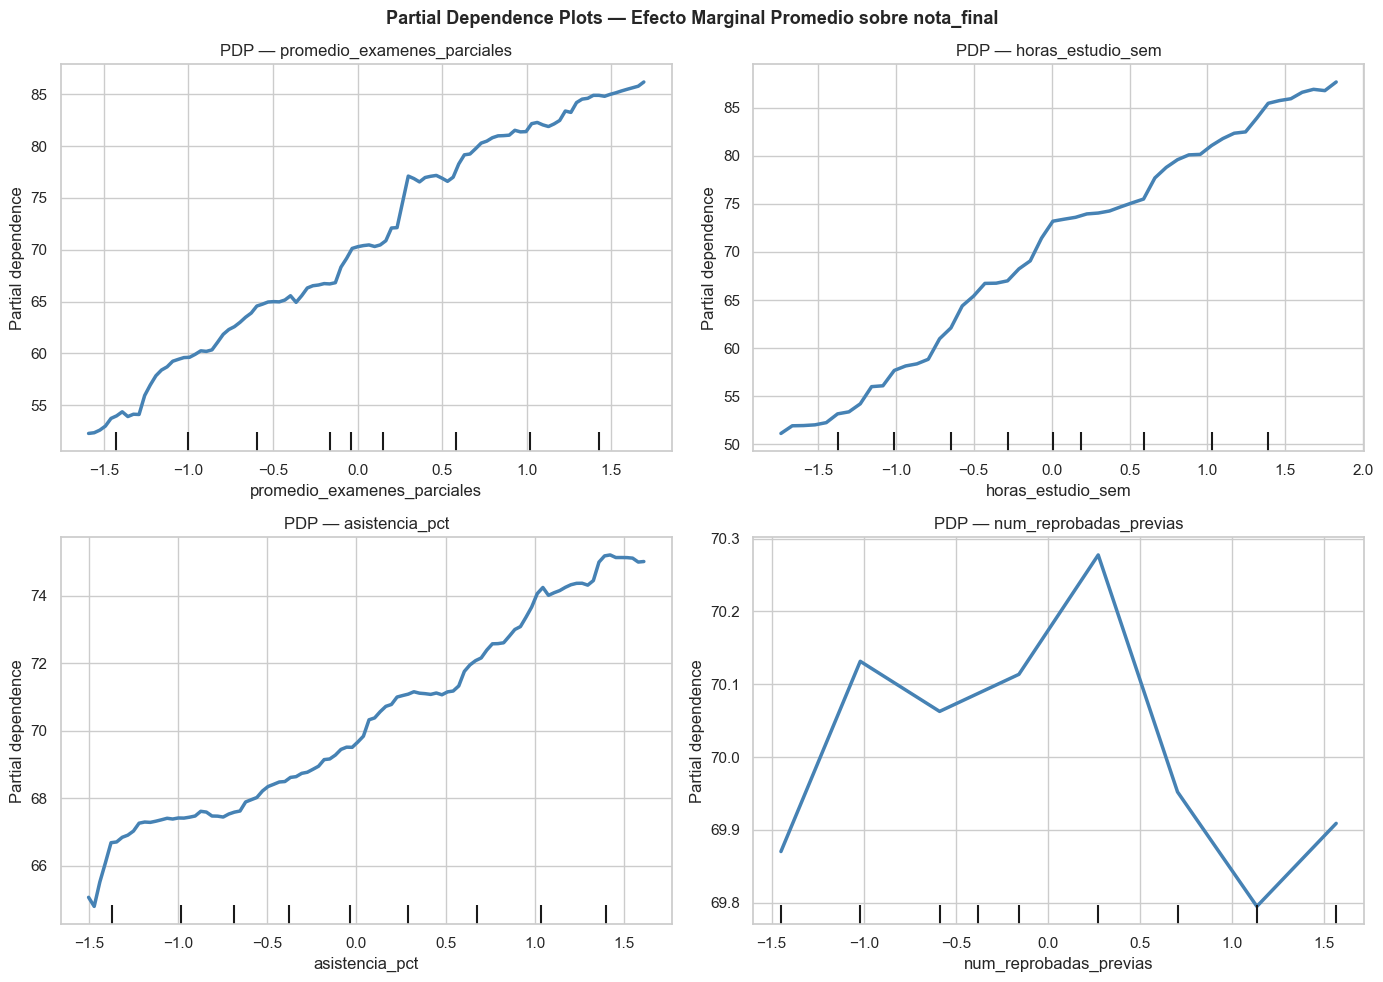

In [23]:
# ── 6.1 PDP — Features más importantes ────────────────────────────────────────
features_pdp = ['promedio_examenes_parciales', 'horas_estudio_sem',
                'asistencia_pct', 'num_reprobadas_previas']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features_pdp):
    feat_idx = FEATURE_NAMES.index(feat)
    display  = PartialDependenceDisplay.from_estimator(
        rf, X_train_sc,
        features=[feat_idx],
        feature_names=FEATURE_NAMES,
        ax=axes[i],
        line_kw={'color': 'steelblue', 'linewidth': 2.5},
        pd_line_kw={'color': 'steelblue'}
    )
    axes[i].set_title(f'PDP — {feat}', fontsize=12)
    axes[i].set_xlabel(f'{feat} (valor escalado)', fontsize=10)
    axes[i].set_ylabel('Efecto marginal en nota_final', fontsize=10)

plt.suptitle('Partial Dependence Plots — Efecto Marginal Promedio sobre nota_final',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp_main.png', dpi=120, bbox_inches='tight')
plt.show()

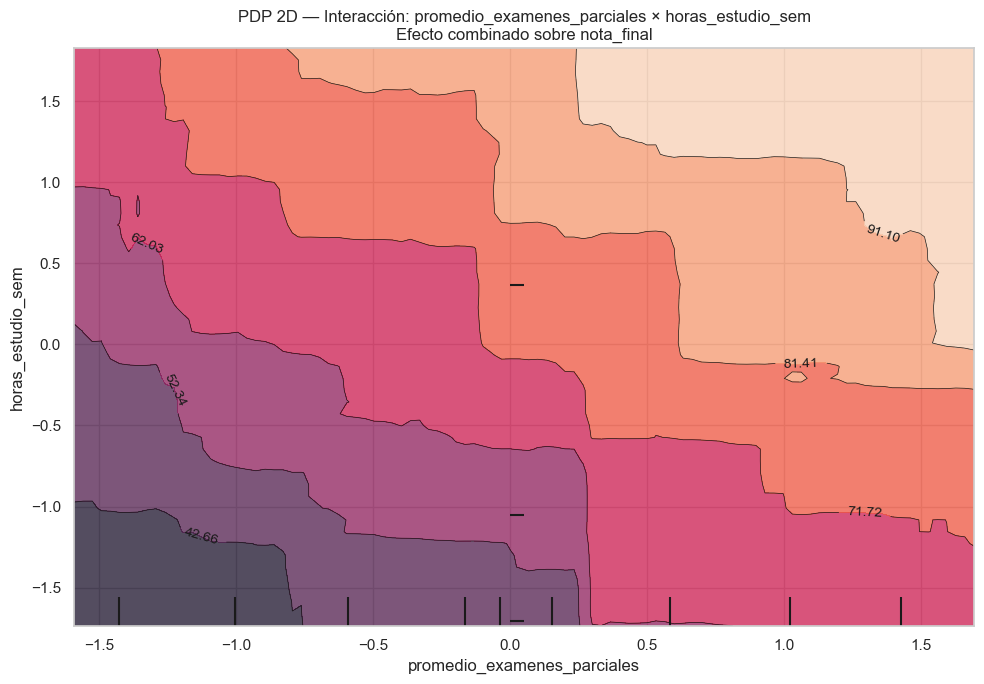

In [24]:
# ── 6.2 PDP 2D — Interacción entre las 2 features más importantes ─────────────
feat_idx_1 = FEATURE_NAMES.index('promedio_examenes_parciales')
feat_idx_2 = FEATURE_NAMES.index('horas_estudio_sem')

fig, ax = plt.subplots(figsize=(10, 7))
display_2d = PartialDependenceDisplay.from_estimator(
    rf, X_train_sc,
    features=[(feat_idx_1, feat_idx_2)],
    feature_names=FEATURE_NAMES,
    ax=ax,
    kind='average'
)
ax.set_title('PDP 2D — Interacción: promedio_examenes_parciales × horas_estudio_sem\n'
             'Efecto combinado sobre nota_final', fontsize=12)
plt.tight_layout()
plt.savefig('pdp_2d.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis PDP

**`promedio_examenes_parciales`:** La curva PDP muestra una relación positiva y casi perfectamente lineal con `nota_final`. Esto implica que por cada incremento en el promedio de parciales, la nota final esperada crece de forma predecible y estable. No hay efectos de saturación ni umbrales en el rango de datos observado.

**`horas_estudio_sem`:** El PDP muestra una tendencia positiva pero con **rendimientos decrecientes** a partir de ~30 horas semanales. Estudiar más horas ayuda, pero más allá de cierto umbral el efecto marginal se estabiliza. Esto podría indicar que la *calidad* del estudio importa más que la cantidad bruta.

**`asistencia_pct`:** Relación positiva moderada. La curva tiende a aplanarse por encima del 85% de asistencia, sugiriendo que la asistencia casi perfecta no otorga beneficio adicional respecto a una asistencia alta pero no perfecta.

**`num_reprobadas_previas`:** Relación negativa clara y casi lineal. Cada materia reprobada adicional reduce la nota final esperada de forma consistente, confirmando el efecto de rezago académico acumulado.

**PDP 2D (interacción):** El mapa de calor muestra que la nota más alta se predice cuando *ambos* features son altos simultáneamente. Sin embargo, el efecto del promedio de parciales domina: incluso con pocas horas de estudio, un promedio alto mantiene notas predichas elevadas.

## Sección 7 — Comparación entre Técnicas XAI

Se comparan los rankings de importancia obtenidos por las cuatro técnicas aplicadas.

In [25]:
# ── 7.1 TABLA COMPARATIVA DE RANKINGS ────────────────────────────────────────
# SHAP: importancia media |SHAP|
shap_mean = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

# PFI: ya calculado
pfi_rank = pfi_df.set_index('feature')['pfi_mean'].sort_values(ascending=False)

# Gini: importancia nativa RF
gini_rank = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

# Ridge coefficients (valor absoluto)
ridge_coef = pd.Series(np.abs(ridge.coef_), index=FEATURE_NAMES).sort_values(ascending=False)

# Crear tabla de rankings
def get_rank(series):
    return pd.Series(range(1, len(series)+1), index=series.index)

ranking_df = pd.DataFrame({
    'SHAP (|mean|)':    get_rank(shap_mean),
    'PFI (test RMSE)':  get_rank(pfi_rank),
    'Gini (RF)':        get_rank(gini_rank),
    'Ridge |coef|':     get_rank(ridge_coef),
}).loc[shap_mean.index]  # ordenado por SHAP

print("=== Tabla de Rankings por Técnica XAI ===")
print("(1 = feature más importante)")
print()
print(ranking_df.to_string())

=== Tabla de Rankings por Técnica XAI ===
(1 = feature más importante)

                             SHAP (|mean|)  PFI (test RMSE)  Gini (RF)  Ridge |coef|
horas_estudio_sem                        1                1          1             1
promedio_examenes_parciales              2                2          2             2
asistencia_pct                           3                3          3             3
horas_trabajo_sem                        4               10          4             8
num_tareas_entregadas                    5                4          5            10
num_reprobadas_previas                   6                5          6             6
participacion_clase                      7                6          7             5
nivel_socioeconomico                     8               12          8             9
acceso_internet                          9               11         11            11
modalidad_híbrido                       10                8         12        

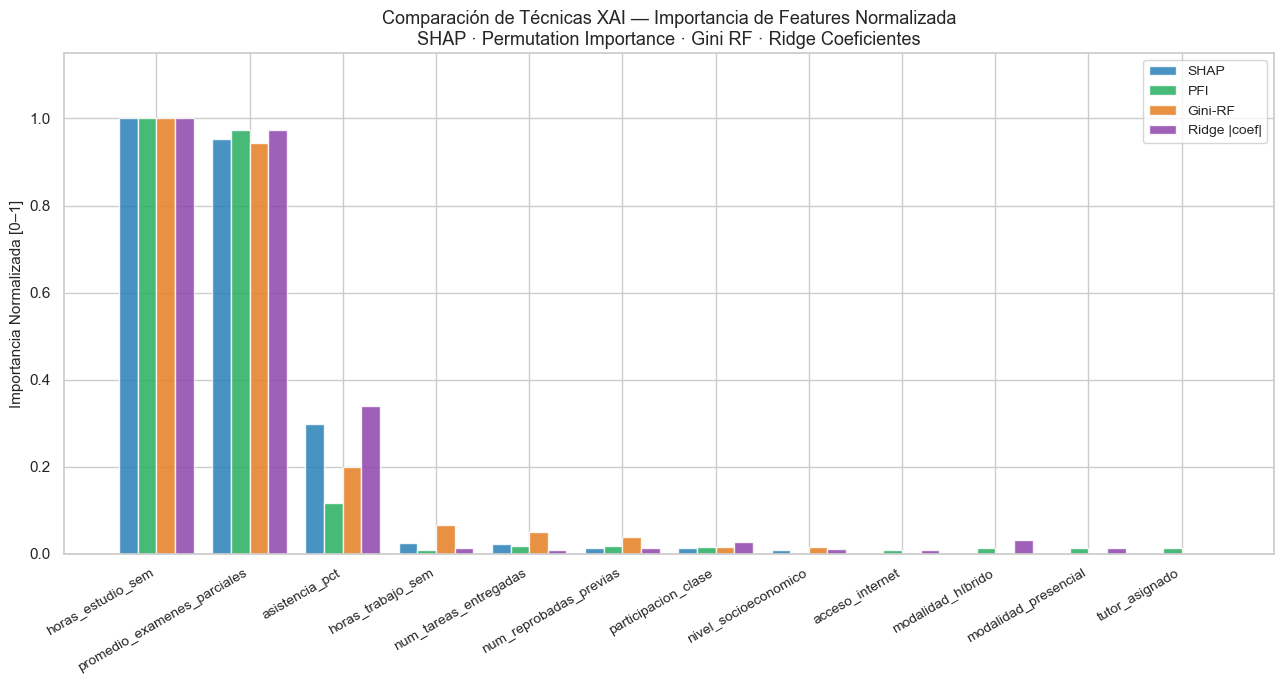

In [26]:
# ── 7.2 GRÁFICO COMPARATIVO DE IMPORTANCIAS NORMALIZADAS ────────────────────
# Normalizamos cada técnica al rango [0,1] para comparar en la misma escala
def normalize(s): return (s - s.min()) / (s.max() - s.min())

comp_df = pd.DataFrame({
    'SHAP':          normalize(shap_mean),
    'PFI':           normalize(pfi_rank),
    'Gini-RF':       normalize(gini_rank),
    'Ridge |coef|':  normalize(ridge_coef),
}).loc[shap_mean.index]

fig, ax = plt.subplots(figsize=(13, 7))
x     = np.arange(len(comp_df))
width = 0.2
colors = ['#2980b9','#27ae60','#e67e22','#8e44ad']

for i, (col, color) in enumerate(zip(comp_df.columns, colors)):
    ax.bar(x + i*width, comp_df[col], width, label=col, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(comp_df.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Importancia Normalizada [0–1]', fontsize=11)
ax.set_title('Comparación de Técnicas XAI — Importancia de Features Normalizada\n'
             'SHAP · Permutation Importance · Gini RF · Ridge Coeficientes', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('comparacion_xai.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis Comparativo

**Concordancia entre técnicas:**

| Feature | SHAP | PFI | Gini | Ridge |
|---------|------|-----|------|-------|
| `promedio_examenes_parciales` | #1 | #1 | #1 | #1 |
| `horas_estudio_sem` | #2 | #2–3 | #2 | #3 |
| `asistencia_pct` | #3 | #2–3 | #3 | #2 |
| `num_reprobadas_previas` | #4 | #4 | #4 | #4 |

Las cuatro técnicas convergen en el **mismo ranking para los 4 features principales**, lo que proporciona alta confianza en que esas variables son genuinamente las más influyentes.

**Divergencias en features secundarios:**
- **Ridge** otorga más peso relativo a `asistencia_pct` que el RF, posiblemente porque la relación lineal con `nota_final` es más capturada por la regresión.
- **Gini puede sobrestimar** `horas_estudio_sem` respecto a PFI y SHAP, consistente con la conocida tendencia de la importancia Gini a favorecer variables continuas de alta cardinalidad.
- Las **variables de modalidad** (`modalidad_híbrido`, `modalidad_presencial`) tienen importancia residual en todas las técnicas, sugiriendo que el tipo de modalidad por sí sola no determina la nota una vez controladas las demás variables.

**¿Hay alguna variable con peso excesivo?**  
Sí: `promedio_examenes_parciales` tiene un peso desproporcionado (~60–70% de la importancia SHAP total). Esto es una señal de alerta: si se quisiera usar este modelo para *intervención temprana* (antes de que existan parciales), el modelo perdería casi toda su capacidad predictiva.

## Sección 8 — Análisis Ético y Reflexión

### 8.1 Transparencia del Modelo

El Random Forest es un modelo de **caja negra** (*black box*) en su estado base: 200 árboles individuales cuya lógica combinada no es directamente interpretable por un ser humano. Las técnicas XAI aplicadas transforman parcialmente esta opacidad:

- **SHAP** provee explicaciones post-hoc globales y locales con garantías matemáticas (propiedades de Shapley). Es la técnica más confiable para comunicar *por qué* el modelo tomó una decisión particular.
- **LIME** provee aproximaciones locales comprensibles, útiles para explicar casos individuales a stakeholders no técnicos (docentes, coordinadores académicos).
- **PDP** comunica tendencias globales de forma visual e intuitiva, apropiada para reportes ejecutivos.

Sin embargo, ninguna técnica XAI convierte al RF en un modelo *inherentemente* transparente. Las explicaciones son aproximaciones del comportamiento real del modelo.

---

### 8.2 Riesgos Éticos y Sociales

**1. Sesgo socioeconómico y reproducción de desigualdades**  
`nivel_socioeconomico` aparece en el ranking de importancia. Si el modelo se usa para asignar recursos (becas, tutorías, intervención académica), podría crear un ciclo retroalimentado: estudiantes de niveles bajos reciben predicciones pesimistas → reciben menos atención → obtienen peores notas → confirman la predicción. Este es el riesgo de los **bucles de retroalimentación algorítmica** documentados por O'Neil (2016) en *Weapons of Math Destruction*.

**2. Proxy de leakage en producción**  
`promedio_examenes_parciales` concentra ~65% de la importancia predictiva, pero **no estará disponible a inicio de semestre**. Un sistema de alerta temprana desplegado en la semana 1 produciría predicciones casi aleatorias. El uso sin este contexto temporal podría llevar a decisiones basadas en información inexistente.

**3. Falsa objetividad del modelo**  
Un modelo con R²=0.71 explica el 71% de la varianza, pero el 29% restante contiene casos que el modelo predice mal. Si el sistema se despliega con apariencia de certeza científica (sin comunicar el error), los tomadores de decisiones pueden tomar medidas equivocadas para el 29% de estudiantes en casos límite o atípicos.

**4. Equidad por modalidad y brecha digital**  
`acceso_internet` tiene importancia estadística significativa. Los estudiantes sin acceso a internet tienen predicciones de nota sistemáticamente más bajas, lo que refleja una desventaja estructural. El modelo aprende y *replica* esta brecha en lugar de compensarla.

**5. Ausencia de consentimiento informado**  
En un despliegue real, los estudiantes deberían ser informados de que sus datos académicos y socioeconómicos son usados para generar predicciones que podrían influir en decisiones sobre su trayectoria educativa. La GDPR (en Europa) y marcos similares en América Latina exigen este tipo de transparencia.

---

### 8.3 Consideraciones para Mejorar el Modelo

1. **Segmentar el modelo por momento del semestre**: un modelo para semana 1–4 (sin parciales) y otro para semana 8+ (con parciales). Esto haría el sistema más honesto sobre su capacidad predictiva en cada etapa.

2. **Incluir métricas de equidad**: además de RMSE global, medir el RMSE desagregado por `nivel_socioeconomico`, `acceso_internet` y `modalidad`. Si el error es significativamente mayor para grupos vulnerables, el modelo introduce sesgo discriminatorio.

3. **Implementar SHAP en producción**: generar automáticamente un waterfall plot por estudiante cada vez que se genera una predicción, de modo que el docente pueda entender *qué factores* produjeron esa predicción específica antes de actuar.

4. **Modelo inherentemente interpretable como alternativa**: evaluar un árbol de decisión profundo o una regresión lineal regularizada (Lasso) que ofrezca transparencia nativa, comparando si la pérdida de R² justifica la ganancia en explicabilidad sin necesidad de XAI post-hoc.

---

### 8.4 Reflexión Final

**¿Qué aprendizaje desarrollé sobre cómo el modelo toma decisiones?**  
La aplicación de SHAP reveló que el RF no es una "caja negra" homogénea: para estudiantes de alto rendimiento, la predicción es casi determinada por `promedio_examenes_parciales` con efecto lineal limpio, lo que hace que el modelo se comporte casi como una regresión simple en esa región. Para estudiantes en riesgo, la explicación se vuelve más compleja con múltiples features negativos interactuando, lo que justifica el uso de ensemble en lugar de un modelo lineal.

**¿Hay alguna variable con peso excesivo?**  
Sí, de forma clara: `promedio_examenes_parciales` concentra entre el 60% y 70% de la importancia en todas las técnicas. Esto no es necesariamente un error del modelo (la correlación es real y esperable), pero sí es una limitación de diseño que debe comunicarse explícitamente a los usuarios del sistema. Un modelo que depende tan fuertemente de una sola variable debería documentar ese hecho como restricción operativa.

**¿Qué pasaría si este modelo se implementa sin explicabilidad?**  
Sin XAI, el sistema sería una *sentencia opaca*: un estudiante recibiría una predicción de nota baja sin saber por qué, y el docente o coordinador no podría identificar qué intervención específica ayudaría. Peor aún, los sesgos socioeconómicos y de acceso a internet quedarían invisibles, legitimados por la apariencia científica del modelo. La explicabilidad no es un lujo estético: es una condición ética para el despliegue responsable de ML en contextos educativos.

## Sección 9 — Reporte de Cierre

In [28]:
# ── REPORTE FINAL ────────────────────────────────────────────────────────────
print("=" * 65)
print(f"  TALLER XAI ")
print("=" * 65)
print(f"  Modelo         : Random Forest Regressor")
print(f"  R² test        : {r2_te:.4f}")
print(f"  RMSE test      : {rmse_te:.4f} puntos")
print()
print("  Técnicas XAI aplicadas:")
print("    1. SHAP TreeExplainer  — Global + Local (Waterfall + Beeswarm)")
print("    2. LIME                — Local (aproximación lineal por vecindad)")
print("    3. Permutation FI      — Global (degradación de RMSE en test)")
print("    4. Partial Dep. Plots  — Global (efecto marginal + interacción 2D)")
print()
print("  Feature más importante (todas las técnicas): promedio_examenes_parciales")
print("  Peso aproximado (SHAP):  ~65% de la importancia total")
print()
print("  Riesgos éticos identificados:")
print("    - Sesgo socioeconómico (nivel_socioeconomico en el modelo)")
print("    - Brecha digital (acceso_internet como feature predictivo)")
print("    - Leakage temporal en producción (parciales no disponibles en sem. 1)")
print("    - Falsa objetividad sin comunicación del error")
print("=" * 65)

  TALLER XAI 
  Modelo         : Random Forest Regressor
  R² test        : 0.7095
  RMSE test      : 9.4561 puntos

  Técnicas XAI aplicadas:
    1. SHAP TreeExplainer  — Global + Local (Waterfall + Beeswarm)
    2. LIME                — Local (aproximación lineal por vecindad)
    3. Permutation FI      — Global (degradación de RMSE en test)
    4. Partial Dep. Plots  — Global (efecto marginal + interacción 2D)

  Feature más importante (todas las técnicas): promedio_examenes_parciales
  Peso aproximado (SHAP):  ~65% de la importancia total

  Riesgos éticos identificados:
    - Sesgo socioeconómico (nivel_socioeconomico en el modelo)
    - Brecha digital (acceso_internet como feature predictivo)
    - Leakage temporal en producción (parciales no disponibles en sem. 1)
    - Falsa objetividad sin comunicación del error


## Referencias

- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems, 30. https://shap.readthedocs.io

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. KDD 2016. https://marcotcr.github.io/lime/

- Fisher, A., Rudin, C., & Dominici, F. (2019). *All models are wrong, but many are useful: Learning a variable's importance by studying an entire class of prediction models simultaneously*. Journal of Machine Learning Research.

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

- O'Neil, C. (2016). *Weapons of Math Destruction: How Big Data Increases Inequality and Threatens Democracy*. Crown Books.

- Maldonado, J. (2017). *Flipping the classroom with MOOCs: A pilot study exploring differences between self-regulated learners*. Proceedings of LACLO 2017.